In [3]:
import torch
from matplotlib import pyplot as plt
import matplotlib.patches as patches

In [4]:
ssd_model = torch.hub.load('NVIDIA/DeepLearningExamples:torchhub', 'nvidia_ssd')
utils = torch.hub.load('NVIDIA/DeepLearningExamples:torchhub', 'nvidia_ssd_processing_utils')
ssd_model.to('cuda')
ssd_model.eval()

Using cache found in C:\Users\vboro/.cache\torch\hub\NVIDIA_DeepLearningExamples_torchhub
C:\Users\vboro/.cache\torch\hub\NVIDIA_DeepLearningExamples_torchhub\PyTorch\Classification\ConvNets\image_classification\models\common.py:13: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(
C:\Users\vboro/.cache\torch\hub\NVIDIA_DeepLearningExamples_torchhub\PyTorch\Classification\ConvNets\image_classification\models\efficientnet.py:17: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(
Using cache found in C:\Users\vboro/.cache\torch\hub\NVIDIA_DeepLearningExamples_torchhub


SSD300(
  (feature_extractor): ResNet(
    (feature_extractor): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplac

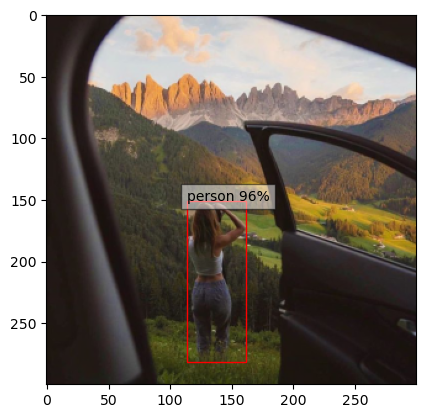

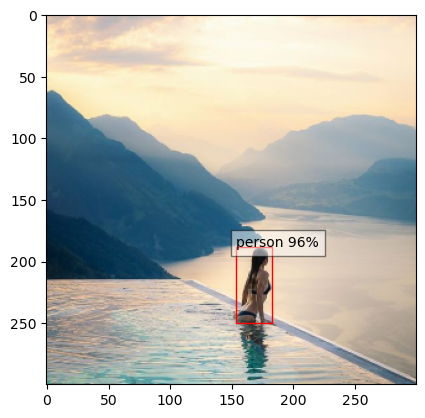

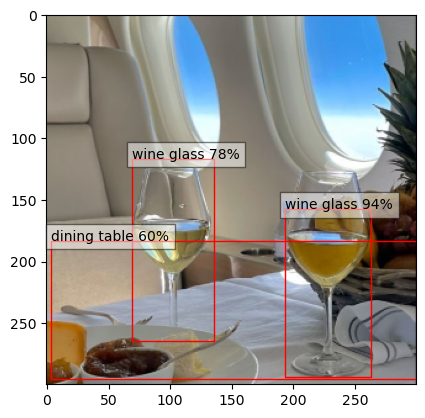

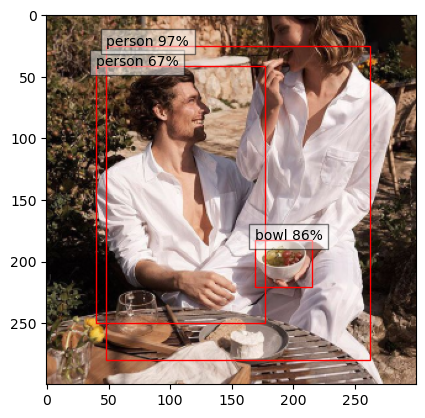

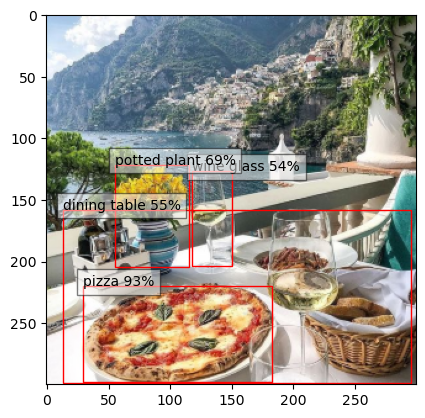

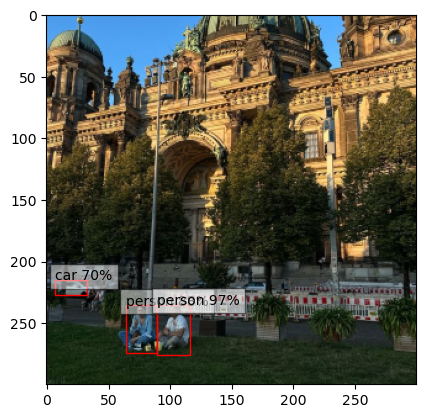

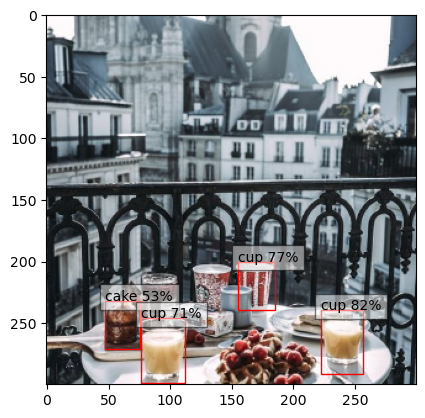

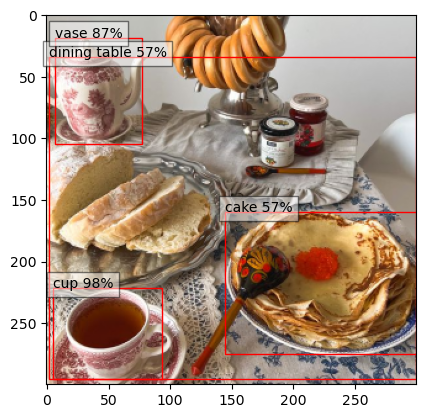

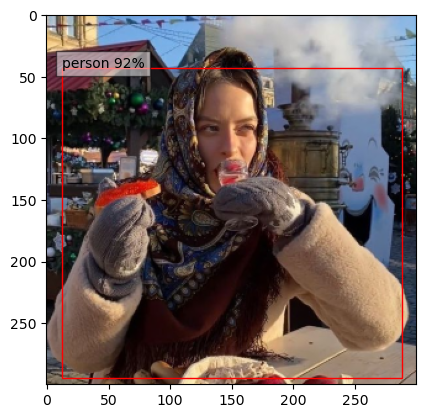

In [6]:
uris = [
    'images/image1.jpg',
    'images/image2.jpg',
    'images/image3.jpg',
    'images/image4.jpg',
    'images/image5.jpg',
    'images/image6.jpg',
    'images/image7.jpg',
    'images/image8.jpg',
    'images/image9.jpg'
]

# Подготовка входных данных
inputs = [utils.prepare_input(uri) for uri in uris]

# Подготовка тензора для модели
tensor = utils.prepare_tensor(inputs)

# Выполнение обнаружения объектов с использованием SSD-модели
with torch.no_grad():
  detections_batch = ssd_model(tensor)

# Декодирование результатов обнаружения
results_per_input = utils.decode_results(detections_batch)

# Выбор лучших результатов с пороговой уверенностью 0.50
best_results_per_input = [utils.pick_best(results, 0.50) for results in results_per_input]

# Получение словаря с соответствием классов меткам
classes_to_labels = utils.get_coco_object_dictionary()

# Итерация по изображениям с лучшими результатами
for image_idx in range(len(best_results_per_input)):
  # Создание графика для визуализации результатов
  fig, ax = plt.subplots(1)

  # Отображение оригинального изображения
  image = inputs[image_idx] / 2 + 0.5
  ax.imshow(image)

  # Отображение прямоугольников вокруг обнаруженных объектов и меток с уверенностью
  bboxes, classes, confidences = best_results_per_input[image_idx]
  for idx in range(len(bboxes)):
    left, bot, right, top = bboxes[idx]
    x, y, w, h = [val * 300 for val in [left, bot, right - left, top - bot]]
    rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor='r', facecolor='none')
    ax.add_patch(rect)

    # Вывод метки класса и уверенности
    ax.text(x, y, "{} {:.0f}%".format(classes_to_labels[classes[idx] - 1], confidences[idx] * 100), bbox=dict(facecolor='white', alpha=0.5))
plt.show()